In [3]:
import pandas as pd
data = pd.read_csv('/content/AB_NYC_2019.csv')

In [4]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
data.shape

(48895, 16)

In [6]:
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [8]:
data.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['price'].describe()

,price
count,48895.000000
mean,152.720687
std,240.154170
min,0.000000
25%,69.000000
50%,106.000000
75%,175.000000
max,10000.000000


In [11]:
(data['price'] == 0).sum()

np.int64(11)

In [14]:
data = data[data['price'] > 0].copy()

In [16]:
data['name'] = data['name'].fillna('Unknown')
data['host_name'] = data['host_name'].fillna('Unknown')

In [17]:
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)

In [18]:
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

In [19]:
data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [20]:
data['has_review'] = data['last_review'].notna()

In [21]:
data['has_review'].value_counts()

,count
has_review,
True,38833
False,10051


In [22]:
data['room_type'].value_counts()

,count
room_type,
Entire home/apt,25407
Private room,22319
Shared room,1158


In [23]:
data['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21660
Brooklyn,20095
Queens,5666
Bronx,1090
Staten Island,373


In [24]:
data.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

,price
neighbourhood_group,
Manhattan,196.884903
Brooklyn,124.438915
Staten Island,114.812332
Queens,99.517649
Bronx,87.577064


In [25]:
data.groupby('room_type')['price'].mean().sort_values(ascending=False)

,price
room_type,
Entire home/apt,211.810918
Private room,89.809131
Shared room,70.248705


In [26]:
data['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21660
Brooklyn,20095
Queens,5666
Bronx,1090
Staten Island,373


In [27]:
data['room_type'].value_counts()

,count
room_type,
Entire home/apt,25407
Private room,22319
Shared room,1158


In [28]:
data.groupby(['neighbourhood_group', 'room_type'])['price'].mean()

neighbourhood_group  room_type      
Bronx                Entire home/apt    127.506596
                     Private room        66.890937
                     Shared room         59.800000
Brooklyn             Entire home/apt    178.346202
                     Private room        76.545428
                     Shared room         50.773723
Manhattan            Entire home/apt    249.257994
                     Private room       116.776622
                     Shared room         88.977083
Queens               Entire home/apt    147.050573
                     Private room        71.762456
                     Shared room         69.020202
Staten Island        Entire home/apt    173.846591
                     Private room        62.292553
                     Shared room         57.444444
Name: price, dtype: float64

In [29]:
data.groupby('room_type')['price'].mean().sort_values(ascending=False)

,price
room_type,
Entire home/apt,211.810918
Private room,89.809131
Shared room,70.248705


In [30]:
data.groupby('room_type')['price'].mean().idxmax()

'Entire home/apt'

In [32]:
data.groupby('neighbourhood_group')['price'].mean().idxmax()

'Manhattan'

In [33]:
data.groupby('neighbourhood')['price'].mean().idxmax()

'Fort Wadsworth'

In [34]:
data.loc[data['price'].idxmax()]

,9151
id,7003697
name,Furnished room in Astoria apartment
host_id,20582832
host_name,Kathrine
neighbourhood_group,Queens
neighbourhood,Astoria
latitude,40.7681
longitude,-73.91651
room_type,Private room
price,10000


In [35]:
data.loc[data['price'].idxmax()]

,9151
id,7003697
name,Furnished room in Astoria apartment
host_id,20582832
host_name,Kathrine
neighbourhood_group,Queens
neighbourhood,Astoria
latitude,40.7681
longitude,-73.91651
room_type,Private room
price,10000


In [36]:
data.loc[data['price'].idxmax()]

,9151
id,7003697
name,Furnished room in Astoria apartment
host_id,20582832
host_name,Kathrine
neighbourhood_group,Queens
neighbourhood,Astoria
latitude,40.7681
longitude,-73.91651
room_type,Private room
price,10000


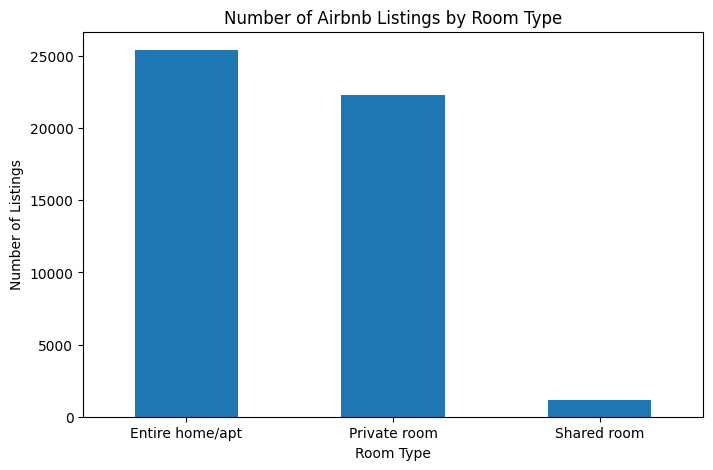

In [37]:
import matplotlib.pyplot as plt

room_counts = data['room_type'].value_counts()

plt.figure(figsize=(8, 5))
room_counts.plot(kind='bar')

plt.title('Number of Airbnb Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

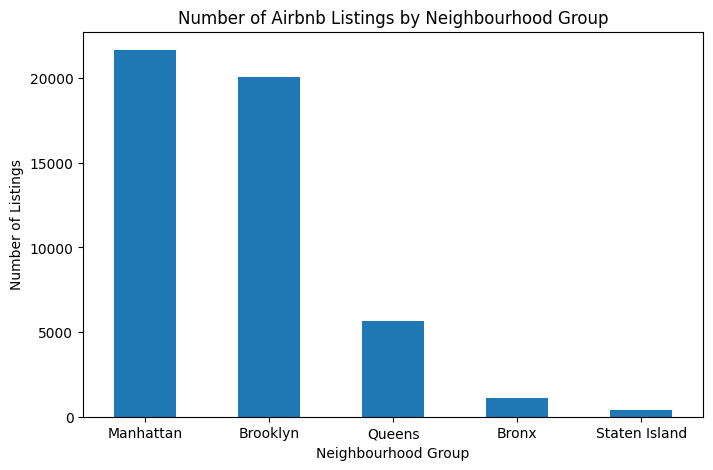

In [38]:
neighbourhood_counts = data['neighbourhood_group'].value_counts()

plt.figure(figsize=(8, 5))
neighbourhood_counts.plot(kind='bar')

plt.title('Number of Airbnb Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

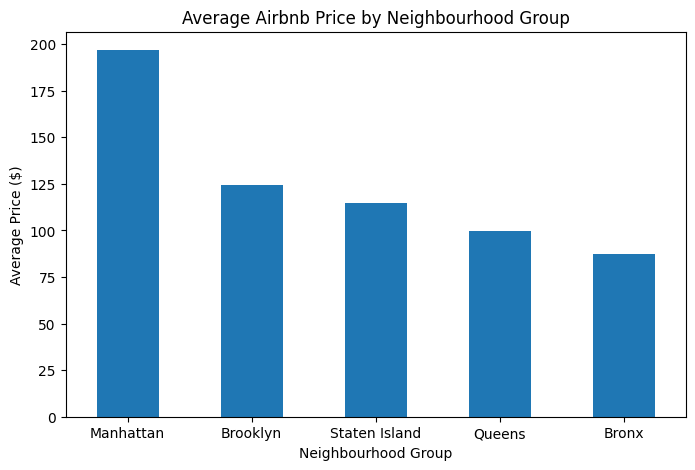

In [39]:
avg_price_neighbourhood = data.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_price_neighbourhood.plot(kind='bar')

plt.title('Average Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.show()

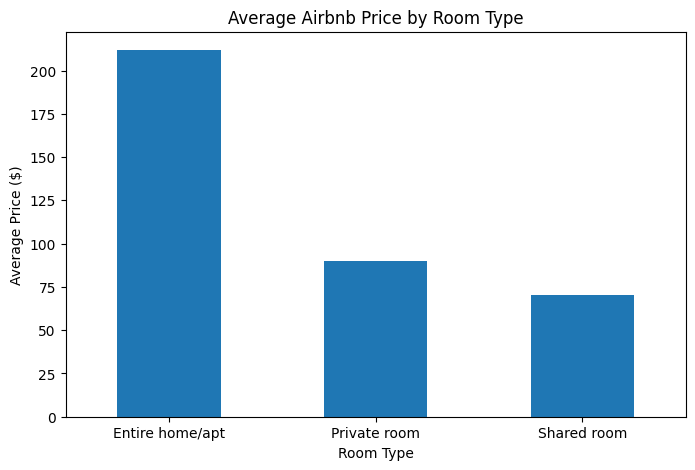

In [40]:
avg_price_room = data.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_price_room.plot(kind='bar')

plt.title('Average Airbnb Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.show()

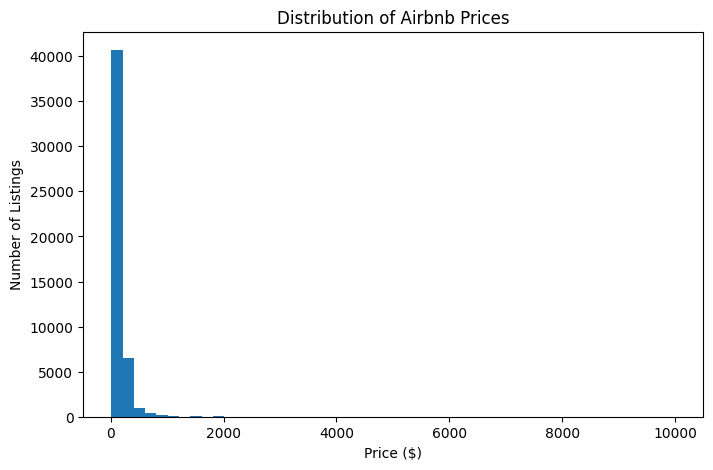

In [41]:
plt.figure(figsize=(8, 5))

plt.hist(data['price'], bins=50)

plt.title('Distribution of Airbnb Prices')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')

plt.show()

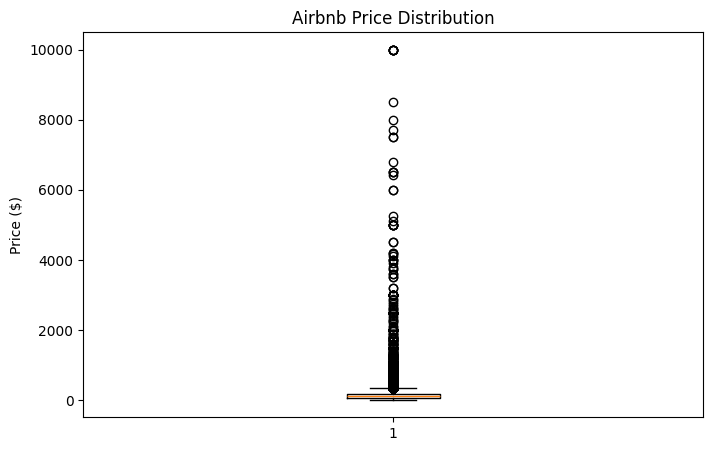

In [42]:
plt.figure(figsize=(8, 5))

plt.boxplot(data['price'])

plt.title('Airbnb Price Distribution')
plt.ylabel('Price ($)')

plt.show()

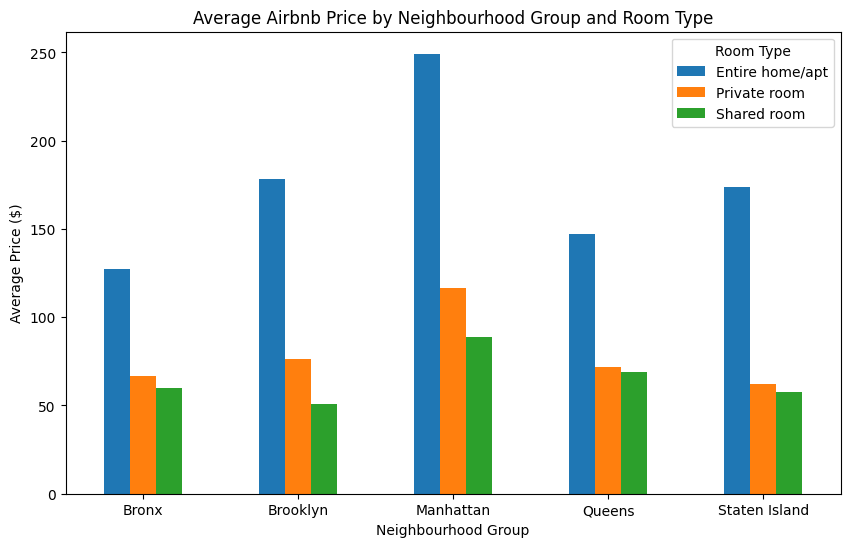

In [43]:
avg_price_room_neighbourhood = data.groupby(
    ['neighbourhood_group', 'room_type']
)['price'].mean().unstack()

avg_price_room_neighbourhood.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Airbnb Price by Neighbourhood Group and Room Type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.legend(title='Room Type')

plt.show()

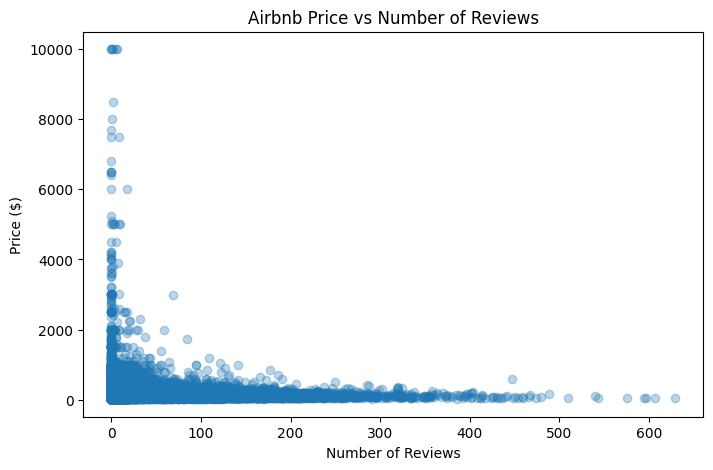

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    data['number_of_reviews'],
    data['price'],
    alpha=0.3
)

plt.title('Airbnb Price vs Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price ($)')

plt.show()

In [45]:
data[['price', 'number_of_reviews']].corr()

,price,number_of_reviews
price,1.000000,-0.047926
number_of_reviews,-0.047926,1.000000


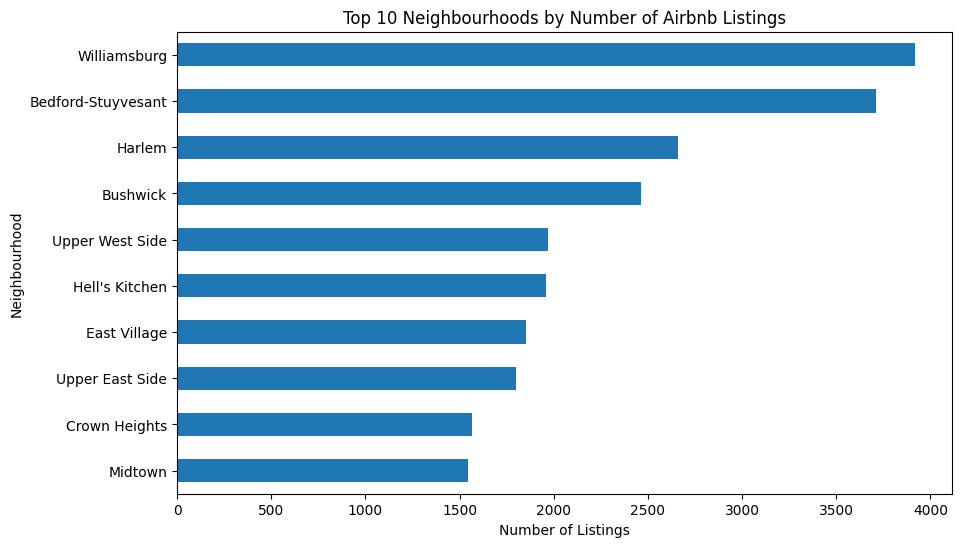

In [46]:
top_neighbourhoods = data['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_neighbourhoods.sort_values().plot(kind='barh')

plt.title('Top 10 Neighbourhoods by Number of Airbnb Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')

plt.show()

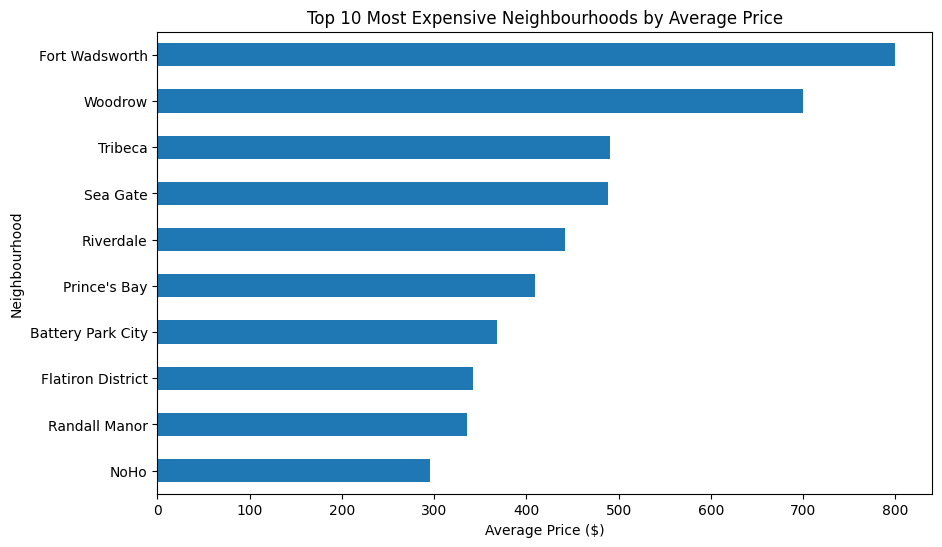

In [47]:
top_expensive_neighbourhoods = (
    data.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_expensive_neighbourhoods.sort_values().plot(kind='barh')

plt.title('Top 10 Most Expensive Neighbourhoods by Average Price')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighbourhood')

plt.show()

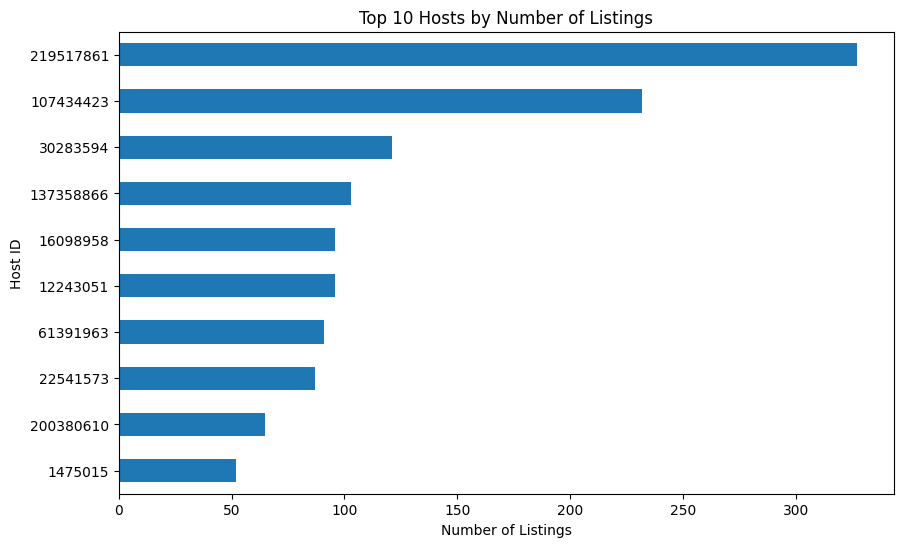

In [49]:
top_hosts = data['host_id'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_hosts.sort_values().plot(kind='barh')

plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host ID')

plt.show()

In [50]:
review_percentage = data['has_review'].value_counts(normalize=True) * 100

review_percentage

,proportion
has_review,
True,79.43908
False,20.56092


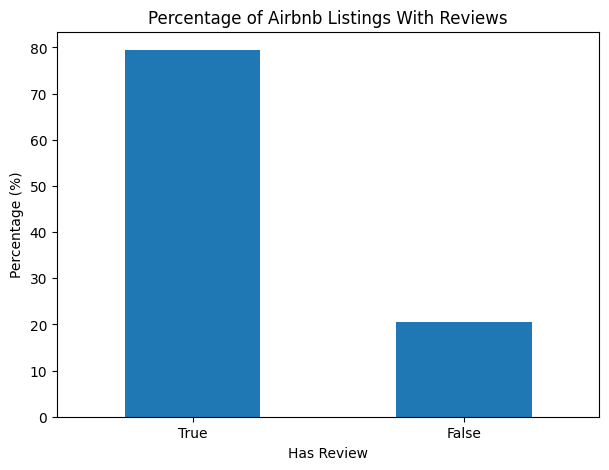

In [51]:
review_percentage.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Percentage of Airbnb Listings With Reviews')
plt.xlabel('Has Review')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

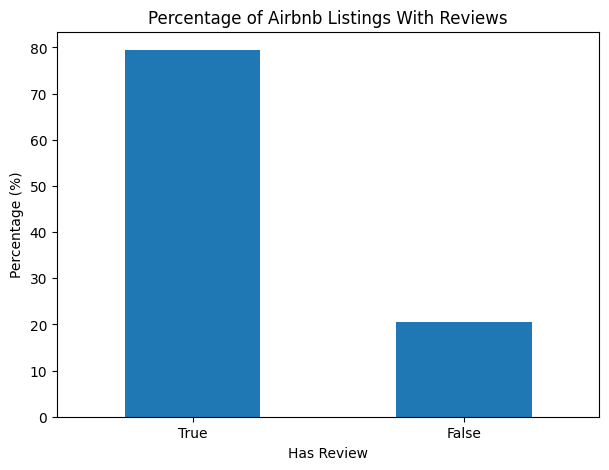

In [52]:
review_percentage.plot(
    kind='bar',
    figsize=(7, 5)
)

plt.title('Percentage of Airbnb Listings With Reviews')
plt.xlabel('Has Review')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.show()

In [53]:
price_by_neighbourhood = data.groupby('neighbourhood_group')['price'].agg(
    ['mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

price_by_neighbourhood

,mean,median,min,max
neighbourhood_group,,,,
Manhattan,196.884903,150.0,10,10000
Brooklyn,124.438915,90.0,10,10000
Staten Island,114.812332,75.0,13,5000
Queens,99.517649,75.0,10,10000
Bronx,87.577064,65.0,10,2500


In [54]:
room_price = data.groupby('room_type')['price'].agg(
    ['mean', 'median', 'count']
).sort_values('mean', ascending=False)

room_price

,mean,median,count
room_type,,,
Entire home/apt,211.810918,160.0,25407
Private room,89.809131,70.0,22319
Shared room,70.248705,45.0,1158


In [55]:
# Correlation between numerical variables

correlation = data[
    ['price', 'minimum_nights', 'number_of_reviews',
     'reviews_per_month', 'availability_365']
].corr()

correlation

,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
price,1.000000,0.042805,-0.047926,-0.050531,0.081847
minimum_nights,0.042805,1.000000,-0.080080,-0.124870,0.144275
number_of_reviews,-0.047926,-0.080080,1.000000,0.589311,0.171975
reviews_per_month,-0.050531,-0.124870,0.589311,1.000000,0.163664
availability_365,0.081847,0.144275,0.171975,0.163664,1.000000


## Key Insights

### 1. Room Type
Entire homes/apartments make up the largest share of Airbnb listings, followed by private rooms. Shared rooms represent a much smaller portion of the listings.

### 2. Location and Pricing
Manhattan has the highest average listing price among the five neighbourhood groups, while the Bronx has the lowest average price.

### 3. Room Type and Pricing
Entire homes/apartments have the highest average price, while shared rooms have the lowest average price.

### 4. Price Distribution
Airbnb prices are strongly right-skewed. Most listings are concentrated at relatively lower prices, while a small number of expensive listings create a long upper tail.

### 5. Reviews
Approximately 79.4% of listings have a recorded review date, while approximately 20.6% do not.

### 6. Price and Reviews
The correlation between price and number of reviews is approximately -0.048, indicating a very weak linear relationship between the two variables.

### 7. Popular Neighbourhoods
Williamsburg and Bedford-Stuyvesant are among the neighbourhoods with the largest numbers of Airbnb listings.

## Conclusion

This exploratory data analysis examined Airbnb listings in New York City using Python and Pandas.

The analysis found clear differences in listing prices across neighbourhood groups and room types. Manhattan had the highest average price among neighbourhood groups, while entire homes/apartments had the highest average price among room types.

The analysis also showed that Airbnb prices are highly skewed, with a relatively small number of very expensive listings. The relationship between price and number of reviews was very weak, suggesting that the number of reviews alone does not have a strong linear relationship with listing price.

Overall, this project demonstrates how data cleaning, exploratory analysis, statistical summaries, correlation analysis, and visualization can be used to identify meaningful patterns in real-world Airbnb data.

## Limitations

- The dataset represents Airbnb listings from New York City in 2019, so the findings may not reflect current Airbnb market conditions.
- Some listings have missing review dates because they may not have received reviews during the recorded period.
- A small number of listings have extremely high prices, which can strongly affect average-price calculations.
- Correlation analysis shows relationships between variables but does not establish causation.
- Neighbourhoods with very few listings can have unstable average prices.

## Project Summary

**Project:** Airbnb NYC 2019 — Exploratory Data Analysis  
**Author:** Anjali Nayak

### Tools Used
- Python
- Pandas
- Matplotlib
- Google Colab

### Analysis Performed
- Data cleaning and missing-value handling
- Descriptive statistics
- Room type analysis
- Neighbourhood analysis
- Price analysis
- Review analysis
- Correlation analysis
- Data visualization

### Dataset
Airbnb NYC 2019 dataset containing information about listings, prices, room types, neighbourhoods, reviews, and availability.